# Where is the Quantum diffusion rate identifiable?

`sigma` is the hopping amplitude in the Quantum Hamiltonian. This notebook asks a question about
the model, not about any dataset: **given 30 trials, which values of `sigma` can be told apart?**

The measure throughout is the expected log-likelihood ratio between two parameter settings,
in nats, over one participant's 30 trials:

$$D(a,b) \;=\; N \sum_{o} p_a(o)\,\log \frac{p_a(o)}{p_b(o)}$$

where $o$ ranges over the model's outcomes: a positive or negative response at each time step,
plus "no valenced response". A gap of $D$ nats is an $e^{D}$ odds ratio, so ~3 nats is weak
evidence and ~10 nats is decisive. No data is used anywhere in this notebook.

In [1]:
import numpy as np, jax, jax.numpy as npx, pandas as pd
from plotnine import *
import cme.decision_models.confidence_accumulation as ca

g++ not available, if using conda: `conda install gxx`


## Configuration

These are the values `fit_emotion_labeling.py` actually runs, not the `ModelDetails` defaults.

In [2]:
n_states, response_width, n_bins = 21, 7, 3
delta, measurement_prob, n_trials = 0.1, 0.75, 30
times = np.round(np.arange(delta, 9.0 + delta / 2, delta), 2)

n_free = n_states - 2 * response_width
Mc, Mw, Mn = ca._get_measurement_matrix(n_states, response_width, measurement_prob, "Quantum")

conc = ca._initial_state_concentration(n_bins, "Quantum")
p_free = ca._expand_bins(conc / conc.sum(), n_free, n_bins)
phi_0 = npx.sqrt(npx.pad(p_free, (response_width, response_width)))[None, None, :, None]

RT = np.asarray(times)[None, :]
RA = np.zeros_like(RT)

## Forward model

`curve` returns the three measurement read-outs at every time on the grid. `Mn` is the survival
operator, so the outcome distribution is the valenced responses at each step plus the mass that
never responded - that is the conservation identity, and it sums to one.

In [3]:
def curve(mu, sigma):
    G = ca.quantum_buildH(n_states, npx.full((1, 1), mu), npx.full((1, 1), sigma), delta)
    phi_t = ca.perform_state_transition(G, RT, RA, Mc, Mw, Mn, phi_0, delta,
                                        transition_type="TIMESTEP", likelihood_type="SINGLE")
    return npx.stack([(npx.abs(M @ phi_t) ** 2).sum(axis=(-2, -1))[0] for M in (Mc, Mw, Mn)])


curves = jax.jit(jax.vmap(curve))


def outcome_mass(c):
    valenced = c[:, :2, :].reshape(c.shape[0], -1)
    survive = npx.clip(1.0 - valenced.sum(axis=1), 1e-12, None)
    return npx.concatenate([valenced, survive[:, None]], axis=1)


def evidence(p):
    p = npx.clip(p, 1e-12, None)
    return np.array(n_trials * (p[:, None, :] * (npx.log(p)[:, None, :] - npx.log(p)[None, :, :])).sum(-1))


check = outcome_mass(curves(npx.asarray([0.76]), npx.asarray([3.16])))
print(f"outcome mass sums to {float(check.sum()):.4f}, response rate {float(check[0, :-1].sum()):.3f}")

outcome mass sums to 1.0000, response rate 0.993


## The predictions themselves

Rows are drift, columns are diffusion. The point of the figure is how the response-time
distribution changes shape with `sigma`: at low values it is a single slow rise, at high values
it breaks into fast oscillation that a 0.1 s grid barely resolves.

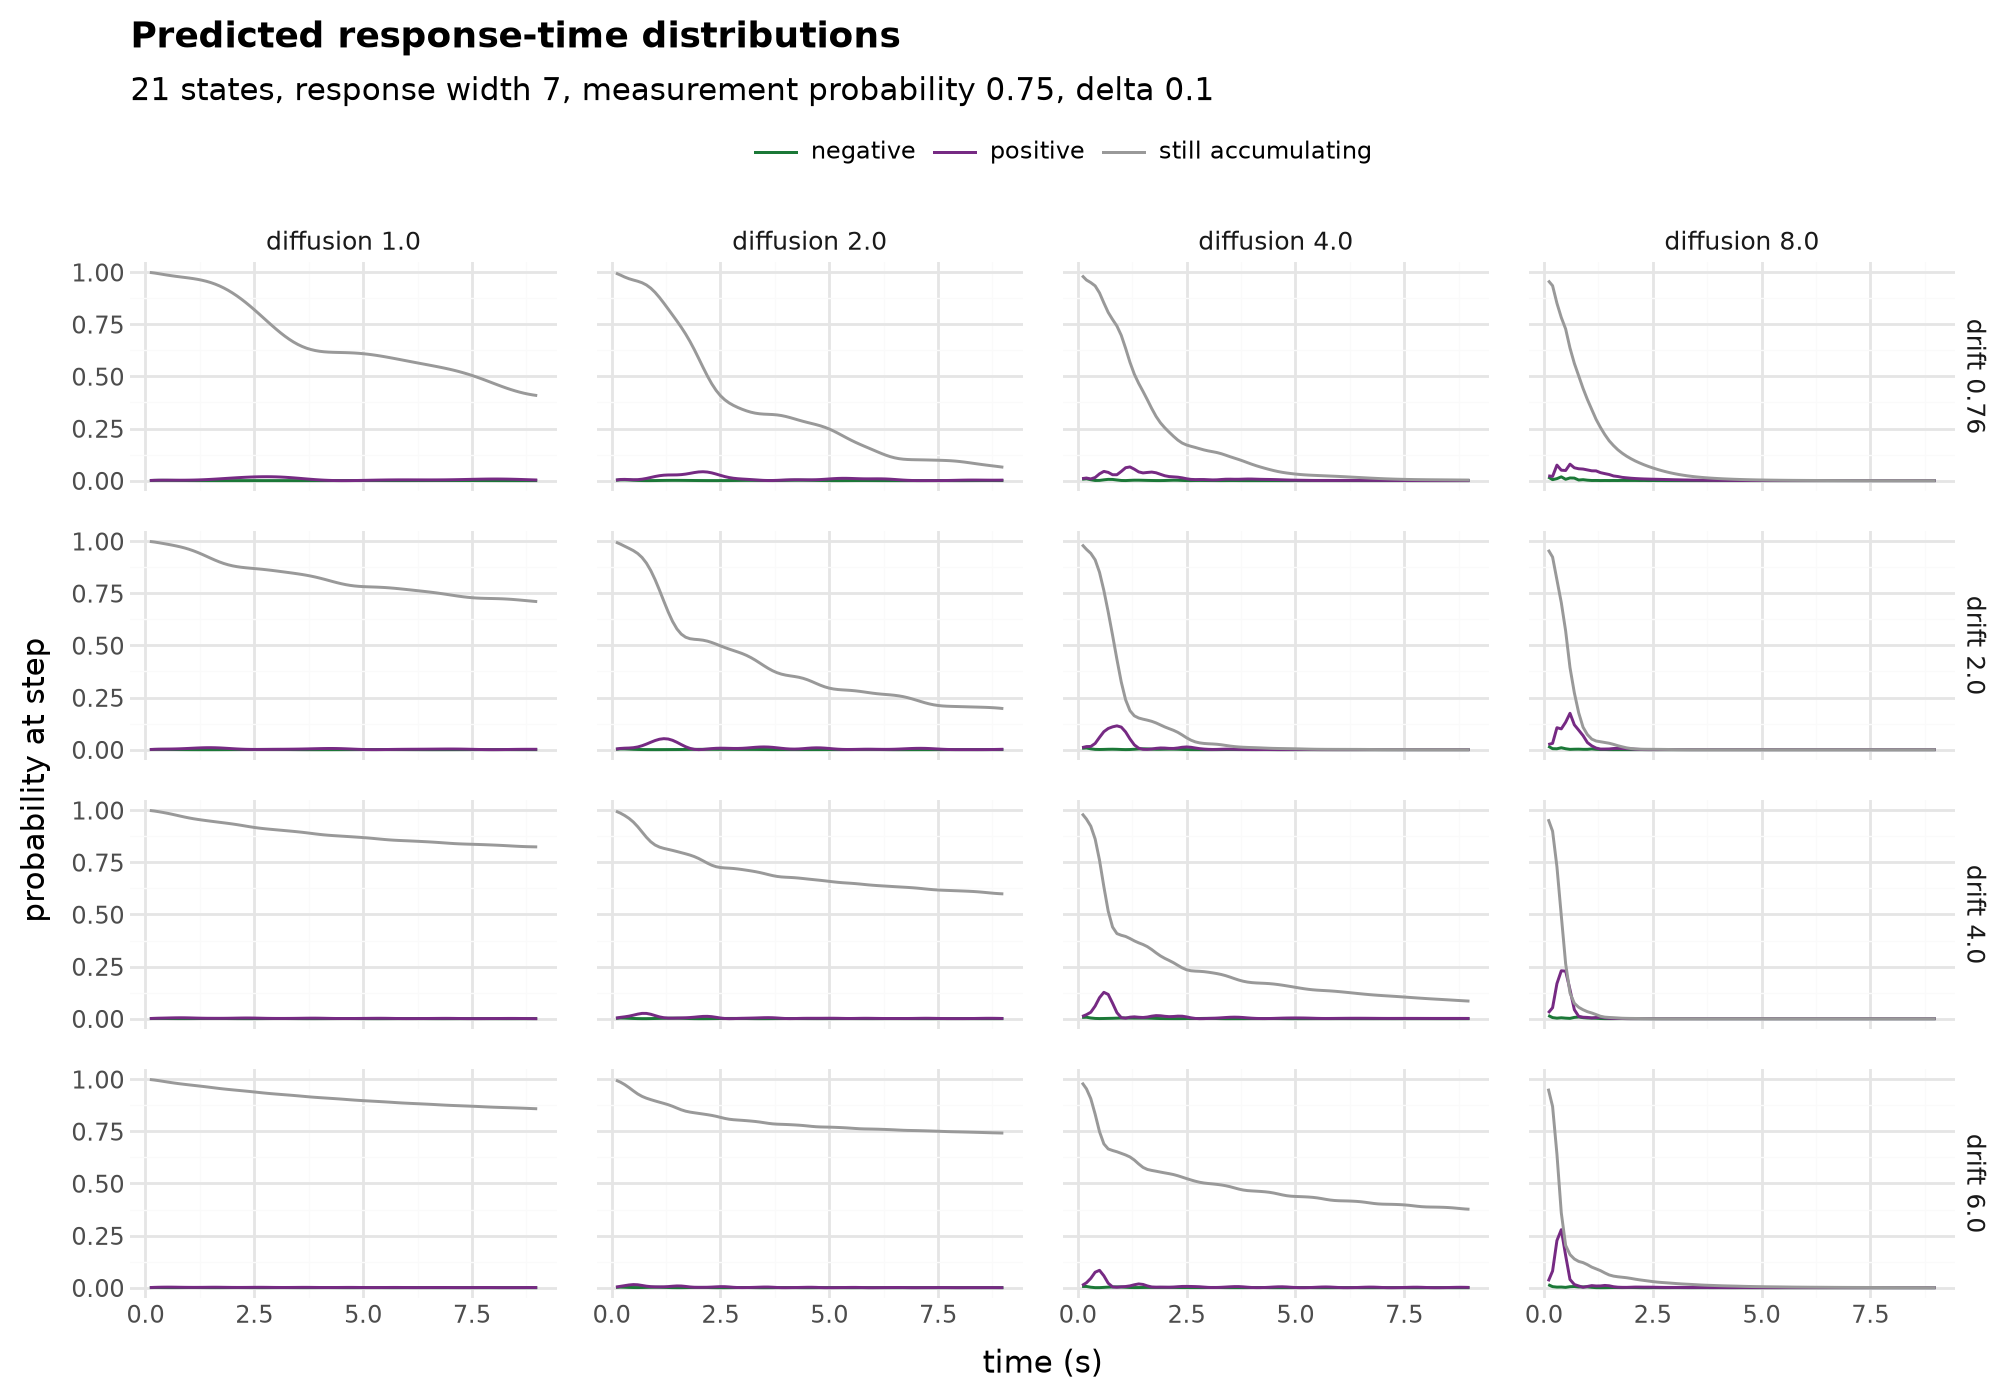

In [4]:
mu_majors = [0.76, 2.0, 4.0, 6.0]
sig_majors = [1.0, 2.0, 4.0, 8.0]

grid = [(m, s) for m in mu_majors for s in sig_majors]
c = curves(npx.asarray([m for m, _ in grid]), npx.asarray([s for _, s in grid]))

rows = []
for (m, s), cc in zip(grid, np.asarray(c)):
    for name, series in zip(["positive", "negative", "still accumulating"], cc):
        rows.append(pd.DataFrame({"t": times, "p": series, "response": name,
                                  "mu": f"drift {m}", "sigma": f"diffusion {s}"}))
pred = pd.concat(rows)
pred["mu"] = pd.Categorical(pred.mu, [f"drift {m}" for m in mu_majors])
pred["sigma"] = pd.Categorical(pred.sigma, [f"diffusion {s}" for s in sig_majors])

(ggplot(pred, aes("t", "p", colour="response"))
 + geom_line(size=0.6)
 + facet_grid("mu ~ sigma", scales="free_y")
 + scale_colour_manual(["#1b7837", "#762a83", "#999999"])
 + labs(x="time (s)", y="probability at step", colour="",
        title="Predicted response-time distributions",
        subtitle="21 states, response width 7, measurement probability 0.75, delta 0.1")
 + theme_minimal()
 + theme(figure_size=(10, 7), legend_position="top", panel_spacing=0.02,
         strip_text=element_text(size=9), plot_title=element_text(size=13, weight="bold")))

## How far apart must two diffusion rates be?

Every pair of `sigma` values on a fine grid, scored in nats over 30 trials. The dark band along
the diagonal is the region the design cannot resolve. It widens sharply to the upper right.

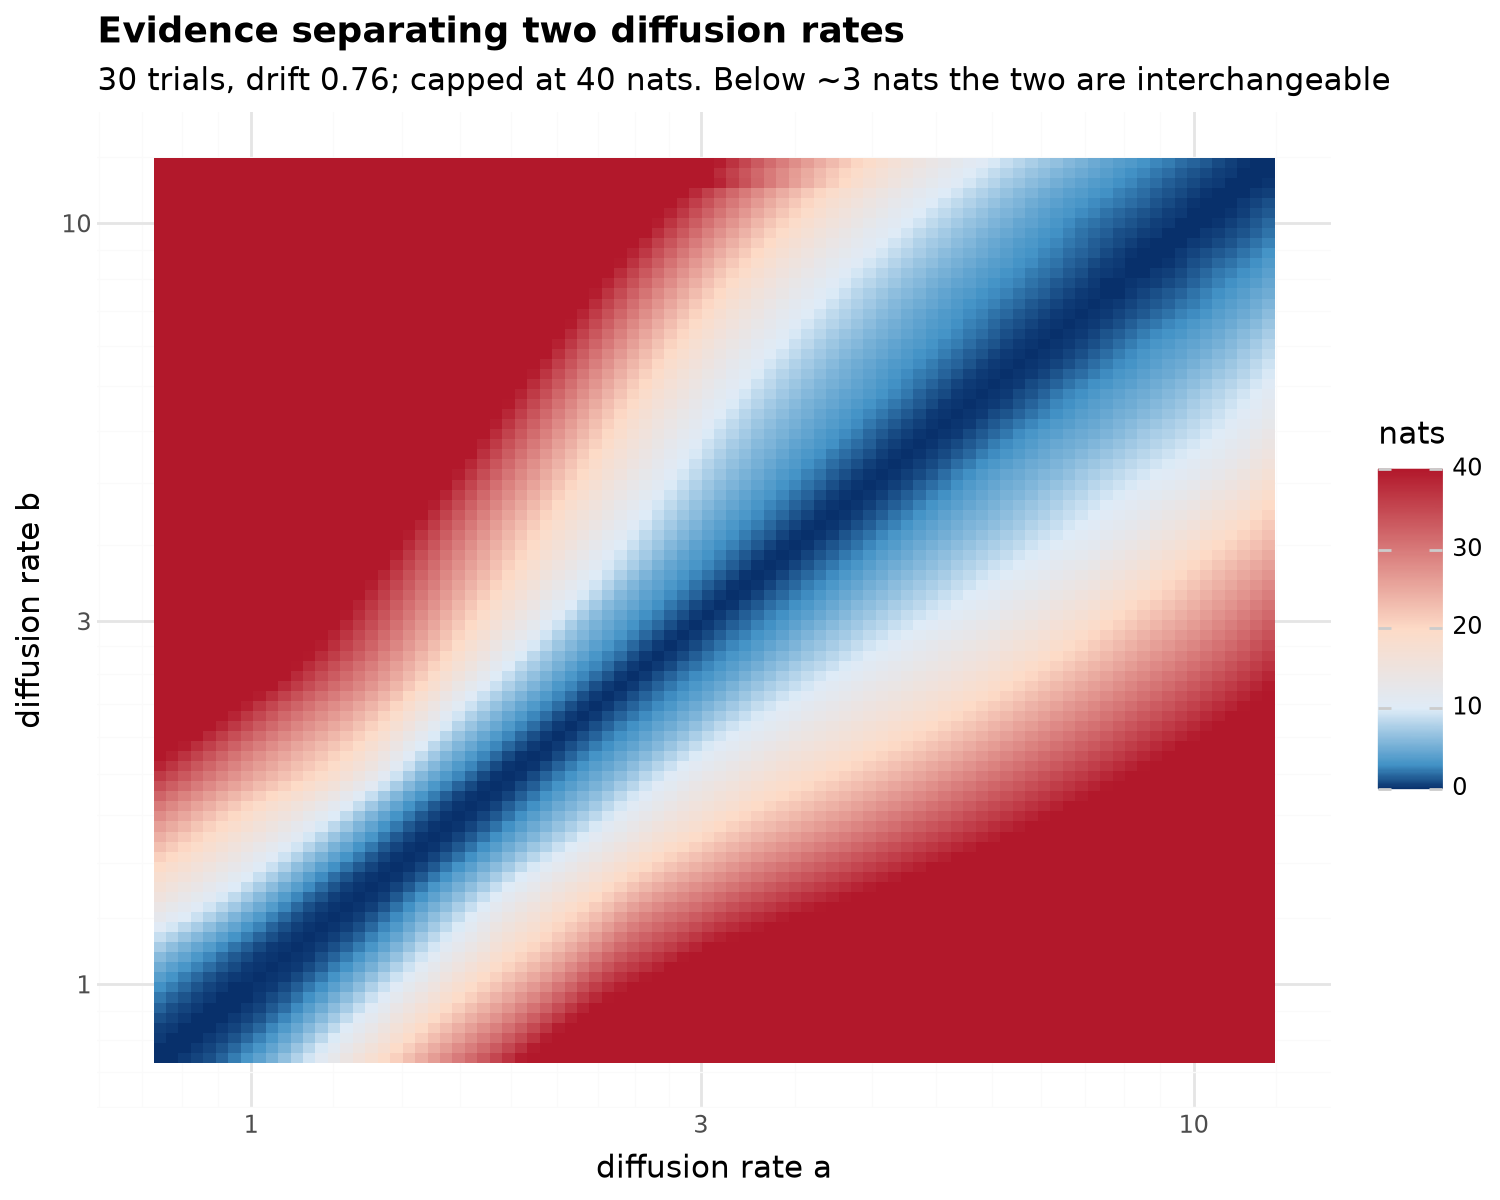

In [5]:
fine = np.geomspace(0.8, 12.0, 90)
mu_ref = 0.76

p_fine = outcome_mass(curves(npx.full(fine.shape, mu_ref), npx.asarray(fine)))
D = evidence(p_fine)

heat = pd.DataFrame([(fine[i], fine[j], min(D[i, j], 40.0))
                     for i in range(len(fine)) for j in range(len(fine))],
                    columns=["sigma_a", "sigma_b", "nats"])

(ggplot(heat, aes("sigma_a", "sigma_b", fill="nats"))
 + geom_raster()
 + scale_x_log10() + scale_y_log10()
 + scale_fill_gradientn(["#08306b", "#4292c6", "#deebf7", "#fddbc7", "#b2182b"],
                        values=[0, 0.075, 0.25, 0.5, 1.0])
 + labs(x="diffusion rate a", y="diffusion rate b", fill="nats",
        title="Evidence separating two diffusion rates",
        subtitle=f"30 trials, drift {mu_ref}; capped at 40 nats. Below ~3 nats the two are interchangeable")
 + theme_minimal()
 + theme(figure_size=(7.5, 6), plot_title=element_text(size=13, weight="bold")))

## Minor perturbations

Your elicitation question directly: holding everything else fixed, does moving `sigma` by 0.1,
0.2 or 0.3 change what the model predicts? The dashed line is 3 nats, the point below which
30 trials cannot separate the two settings.

Read this figure together with the next one. A fixed additive step falls off steeply because
0.3 is a 30% change at `sigma = 1` and a 5% change at `sigma = 6` - most of the decline is that
shrinking ratio, not the model losing sensitivity.

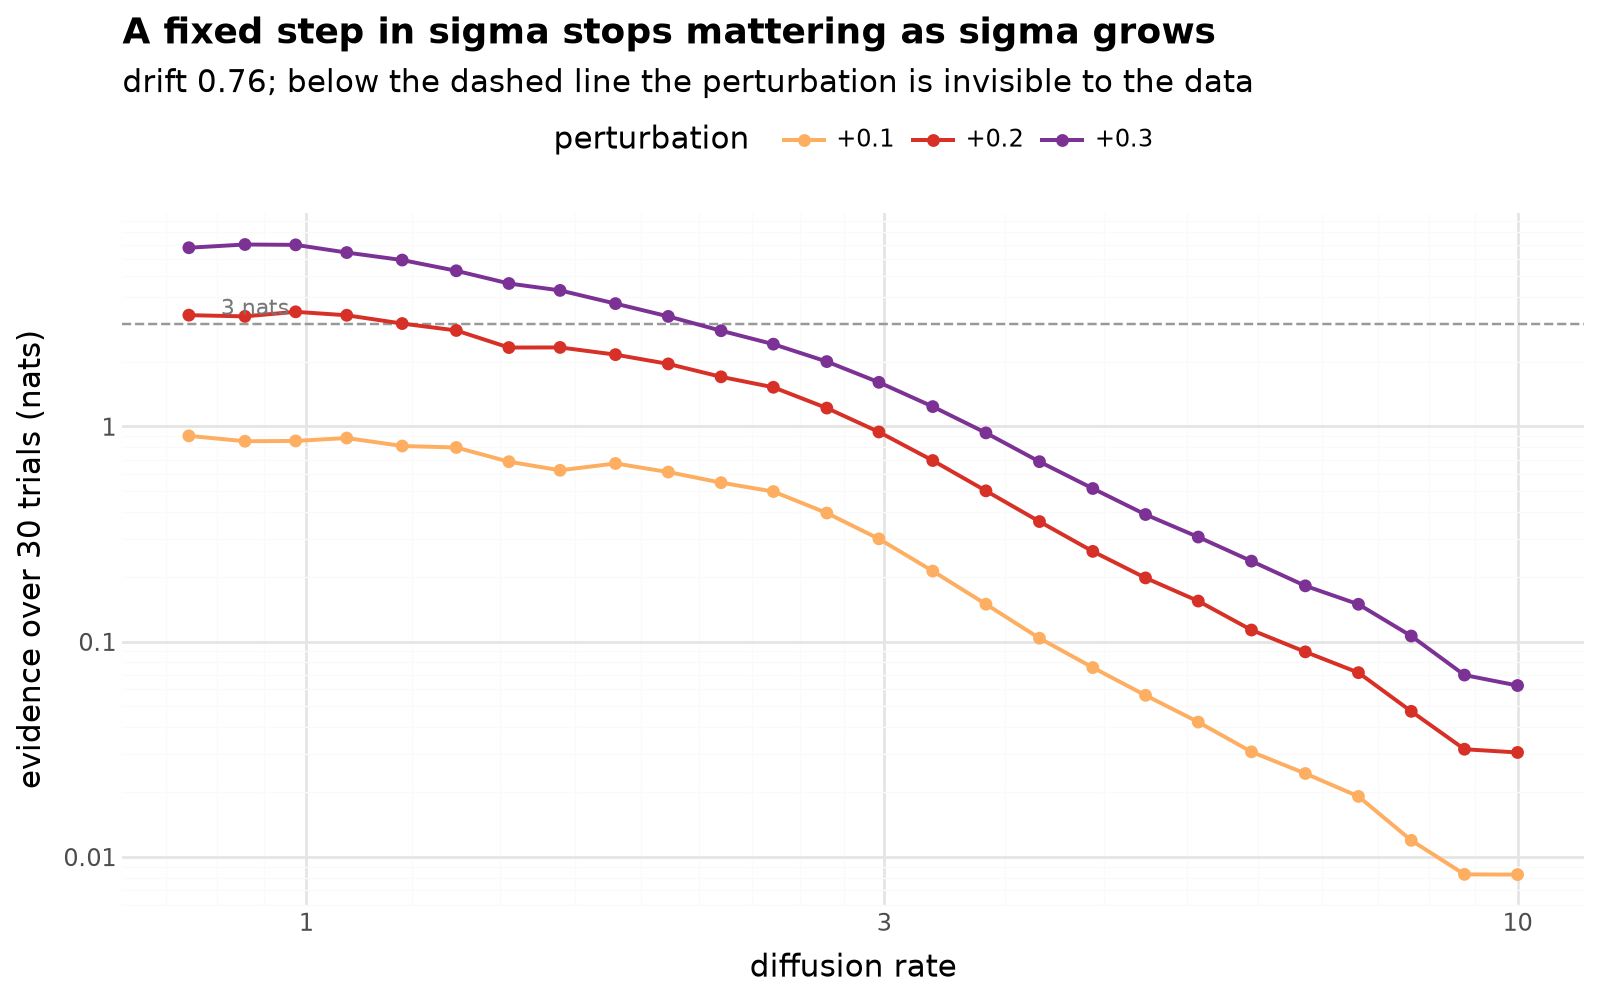

In [6]:
minors = [0.1, 0.2, 0.3]
bases = np.round(np.geomspace(0.8, 10.0, 26), 2)

pairs = [(b, b + d) for b in bases for d in minors]
pp = outcome_mass(curves(npx.full(2 * len(pairs), mu_ref),
                         npx.asarray([v for pair in pairs for v in pair])))
Dm = evidence(pp)
pert = pd.DataFrame({"sigma": [b for b, _ in pairs],
                     "step": [f"+{round(b2 - b, 1)}" for b, b2 in pairs],
                     "nats": [Dm[2 * k, 2 * k + 1] for k in range(len(pairs))]})

(ggplot(pert, aes("sigma", "nats", colour="step"))
 + geom_hline(yintercept=3.0, linetype="dashed", colour="#999999")
 + geom_line(size=0.8) + geom_point(size=1.6)
 + scale_x_log10() + scale_y_log10()
 + scale_colour_manual(["#fdae61", "#d73027", "#7b3294"])
 + annotate("text", x=0.85, y=3.6, label="3 nats", ha="left", size=8, colour="#777777")
 + labs(x="diffusion rate", y="evidence over 30 trials (nats)", colour="perturbation",
        title="A fixed step in sigma stops mattering as sigma grows",
        subtitle=f"drift {mu_ref}; below the dashed line the perturbation is invisible to the data")
 + theme_minimal()
 + theme(figure_size=(8, 5), legend_position="top", plot_title=element_text(size=13, weight="bold")))

## The identifiable window

For each `sigma`, the smallest multiplicative change that a 30-trial design can detect. Low
values are pinned tightly; past about 4 the curve turns over and the model stops being able to
tell neighbouring rates apart at all.

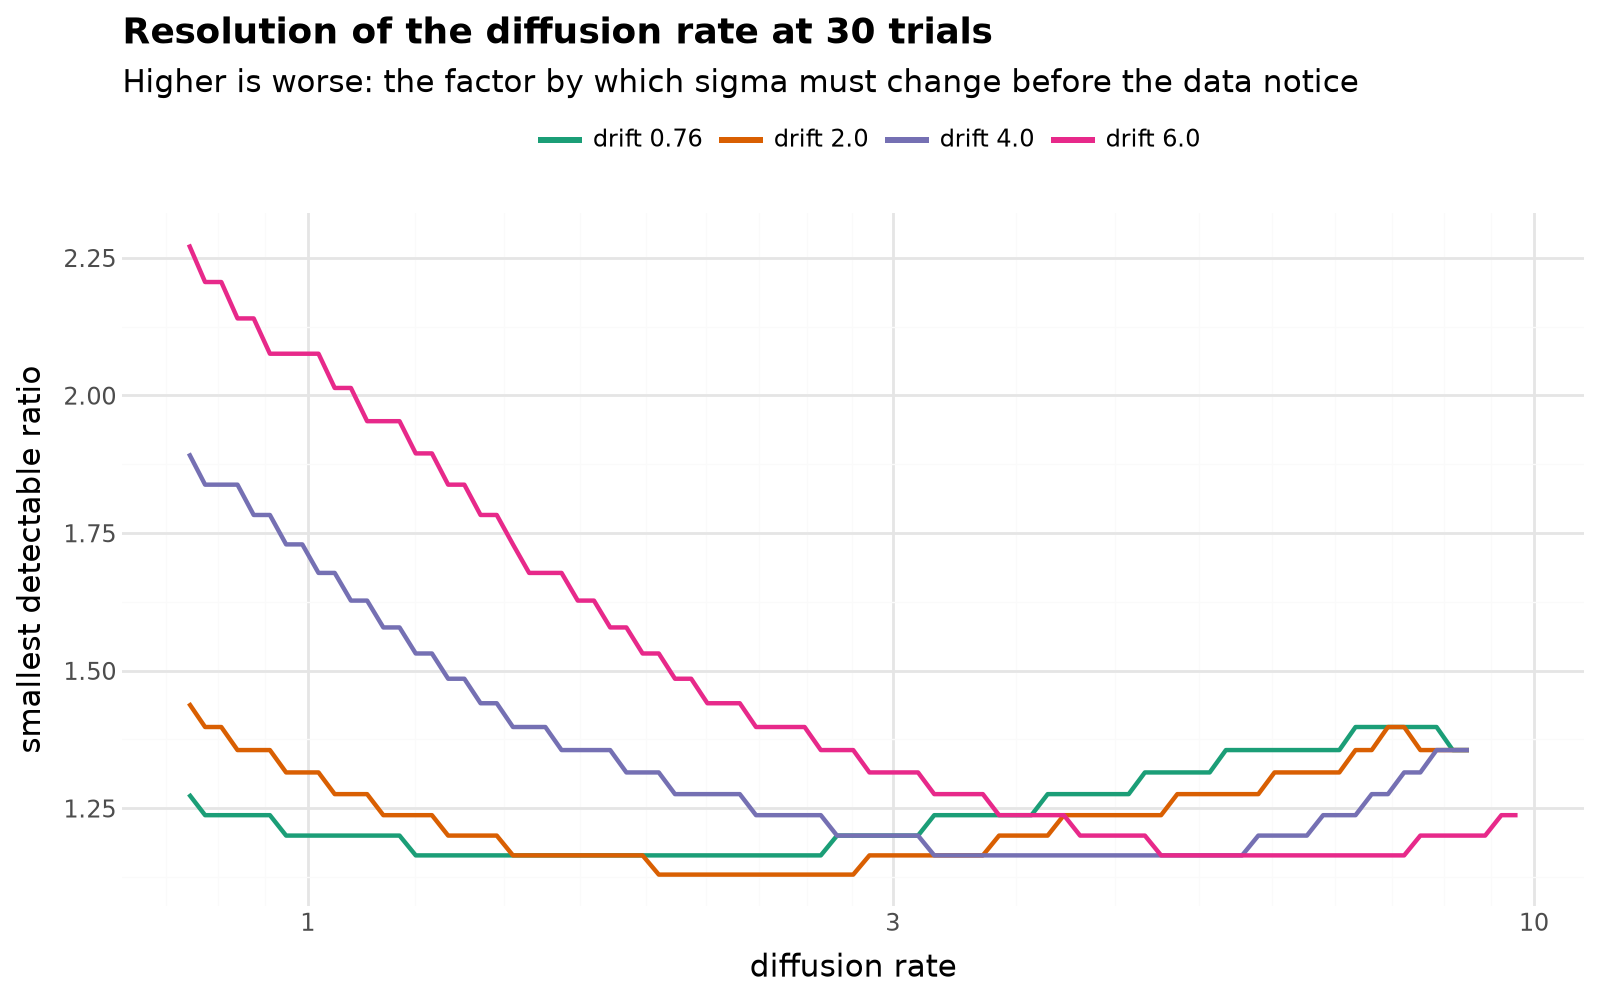

In [7]:
res_rows = []
for mu in mu_majors:
    p_m = outcome_mass(curves(npx.full(fine.shape, mu), npx.asarray(fine)))
    Dmu = evidence(p_m)
    for i, s in enumerate(fine):
        hit = [fine[j] / s for j in range(i + 1, len(fine)) if Dmu[i, j] >= 3.0]
        res_rows.append({"sigma": s, "mu": f"drift {mu}", "ratio": min(hit) if hit else np.nan})
res = pd.DataFrame(res_rows).dropna()
res["mu"] = pd.Categorical(res.mu, [f"drift {m}" for m in mu_majors])

(ggplot(res, aes("sigma", "ratio", colour="mu"))
 + geom_line(size=0.9)
 + scale_x_log10()
 + scale_colour_brewer(type="qual", palette="Dark2")
 + labs(x="diffusion rate", y="smallest detectable ratio", colour="",
        title="Resolution of the diffusion rate at 30 trials",
        subtitle="Higher is worse: the factor by which sigma must change before the data notice")
 + theme_minimal()
 + theme(figure_size=(8, 5), legend_position="top", plot_title=element_text(size=13, weight="bold")))

In [8]:
summary = (res.groupby("mu", observed=True)
             .apply(lambda g: pd.Series({
                 "resolution at sigma 1": g.ratio[np.abs(g.sigma - 1.0).idxmin()],
                 "resolution at sigma 3": g.ratio[np.abs(g.sigma - 3.0).idxmin()],
                 "resolution at sigma 6": g.ratio[np.abs(g.sigma - 6.0).idxmin()],
                 "median resolution": g.ratio.median()}), include_groups=False)
             .round(2))
print(summary.to_string())

            resolution at sigma 1  resolution at sigma 3  resolution at sigma 6  median resolution
mu                                                                                                
drift 0.76                   1.20                   1.20                   1.36               1.22
drift 2.0                    1.32                   1.16                   1.28               1.24
drift 4.0                    1.73                   1.20                   1.20               1.28
drift 6.0                    2.08                   1.32                   1.16               1.36


## What this says about the prior

**Thirty trials resolve the diffusion rate to roughly a factor of 1.2 to 1.4, and that
resolution is close to flat across the whole range.** It does not collapse at large `sigma`.
The steep fall in the previous figure is a ratio effect: a step of 0.3 is a 30% change at
`sigma = 1` and a 5% change at `sigma = 6`, and once that is taken out, sensitivity is
approximately scale-free. The natural parameterisation is therefore logarithmic, which is what
the model already uses via `m_si`.

That sets the prior width directly. A prior on `m_si` narrower than about `log(1.3) / 2 ≈ 0.13`
is pinning `sigma` finer than 30 trials can resolve, so the posterior would be reporting the
prior back. A much wider one spans many mutually distinguishable values, and the likelihood
should then pick one sharply.

**What this rules out.** Rates separated by a factor of two are about 20 nats apart at
`drift 0.76` - an odds ratio of order $10^8$. So two diffusion rates a factor of two apart are
*not* interchangeable under this model, and multimodality at that spacing cannot be explained
as a limitation of the design. If fitted chains settle at two such values, the cause is in the
individual dataset or the sampler's ability to move between separated maxima, not in what the
model can in principle distinguish.

One caveat to keep with the figures: this says which rates are *distinguishable*, not which are
*psychologically right*. That has to come from theory, and in Busemeyer's and Epping's
implementations the diffusion rate is fixed as the unit of the Hamiltonian - `H_off_diag` is a
vector of ones.